# Irish Property Price Register — EDA

Exploring `data/ppr_clean.csv` (last 24 months, cleaned) before building the dashboard.

## Project Goals

1. **Acquire real-world data from an official public source** — Ireland's Property Price Register — via an automated, repeatable pipeline (not a one-off manual download), including verifying the source is legitimately scrapable/usable before building anything.
2. **Clean and validate the data as documented decisions, not silent fixes** — encoding bugs (€ symbol), duplicate/inconsistent categories (Irish-language label), unusable columns (Size Band), and outliers (bulk institutional sales) all get identified, explained, and handled deliberately.
3. **Answer specific market questions through EDA, not just produce charts** — how are prices trending over the last 2 years, where is property most/least expensive by county, how much do data-quality flags (Not Full Market Price, bulk sales) actually change the headline numbers.
4. **Communicate findings through an interactive dashboard** (Streamlit) that a non-technical person could use to explore the data themselves, not just a static report only I can interpret.
5. **Demonstrate a realistic, end-to-end data workflow** — acquisition → cleaning → analysis → communication — mirroring how this would actually be done in a data team, not a notebook full of disconnected plots.

## Analytical Questions This Analysis Answers

1. **How has the Irish property market moved over the last 2 years?** — monthly median price trend, nationally and broken down by county.
2. **Where in Ireland is property most and least expensive right now?** — county-level price comparison, including how large the Dublin premium actually is over the rest of the country.
3. **Do new builds cost more than second-hand homes, and by how much?** — price comparison by property type.
4. **How reliable is the "average price" figure you'd see quoted in the news?** — the mean is pulled well above the median in this data, partly by a small number of institutional bulk sales (entire apartment blocks sold as a single register entry, e.g. "202 Residential Units" at €88M — a normal per-unit price multiplied by 202, not a mansion). The analysis explicitly separates these from individual home sales rather than letting them silently distort the headline numbers.
5. **How much of the recorded market is genuinely open-market pricing?** — the share of transactions flagged as non-arm's-length (family transfers, shared-ownership schemes) and whether including or excluding them meaningfully changes the price statistics.

**What this analysis can't answer:** price-per-square-metre / value-for-size comparisons — PSRA stopped populating the property size field for recent transactions, so that dimension isn't available in current data, and this analysis doesn't pretend otherwise.

## Section 1: Structural Sanity Checks

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/ppr_clean.csv', parse_dates=['Date'])

In [1]:
df.head()

        Date  Year  Month                                              Address  County  Eircode   Price  Not Full Market Price  VAT Exclusive                          Property Type
0 2024-08-23  2024      8                        1 DUN EMER VIEW, LUSK, DUBLIN  Dublin  K45HT66 480,000                  False          False  Second-Hand Dwelling house /Apartment
1 2024-08-23  2024      8                          1 GREEN RD, COOLANEY, SLIGO   Sligo  F56W704 190,000                  False          False  Second-Hand Dwelling house /Apartment
2 2024-08-23  2024      8                    1 HAMLET LANE, BALBRIGGAN, DUBLIN  Dublin  K32P624 200,000                  False          False  Second-Hand Dwelling house /Apartment
3 2024-08-23  2024      8  1 THE ORCHARD, CLOVER HILL RD, CLONDALKIN DUBLIN 22  Dublin  D22PF96 220,000                  False          False  Second-Hand Dwelling house /Apartment
4 2024-08-23  2024      8            1 THE PARKLANDS, CASTLESIDE DR, DUBLIN 14  Dublin  D14RP82

In [1]:
df.shape

(118318, 10)


In [1]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118318 entries, 0 to 118317
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Date                   118318 non-null  datetime64[us]
 1   Year                   118318 non-null  int64         
 2   Month                  118318 non-null  int64         
 3   Address                118318 non-null  str           
 4   County                 118318 non-null  str           
 5   Eircode                88298 non-null   str           
 6   Price                  118318 non-null  float64       
 7   Not Full Market Price  118318 non-null  bool          
 8   VAT Exclusive          118318 non-null  bool          
 9   Property Type          118318 non-null  str           
dtypes: bool(2), datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 16.9 MB


In [1]:
df.isna().sum()

Date                         0
Year                         0
Month                        0
Address                      0
County                       0
Eircode                  30020
Price                        0
Not Full Market Price        0
VAT Exclusive                0
Property Type                0
dtype: int64


In [1]:
df.duplicated().sum()

0


**Takeaway:** 118,318 rows, correctly typed (dates, floats, booleans), zero duplicates — the pipeline's cleaning holds up. `Eircode` is missing for ~25% of rows (worth checking for geographic bias — is it random, or concentrated in rural counties?). `Size Band` was dropped entirely upstream in the pipeline since it's 100% empty for this time window (PSRA stopped populating it for recent transactions).

## Section 2: Univariate Distributions

In [1]:
df['Price'].describe()

count       118,318
mean        459,285
std       2,059,825
min           5,300
25%         255,000
50%         355,000
75%         467,000
max     387,665,198
Name: Price, dtype: float64


**Critical-thinking moment #1:** mean (€459,285) is far above median (€355,000), and the standard deviation (€2,059,825) is *larger than the mean itself*. That combination is a strong statistical tell that a handful of extreme values are distorting everything — worth investigating before trusting any chart built on this column.

In [1]:
df.nlargest(10, 'Price')[['Date', 'Address', 'County', 'Price', 'Not Full Market Price']]

             Date                                                                            Address   County       Price  Not Full Market Price
10124  2024-10-17                                        24 Tinakilly Grove, Tinakilly Park, Rathnew  Wicklow 387,665,198                  False
90372  2026-01-27                                                               Montpelier, Dublin 7   Dublin 225,000,000                   True
25539  2024-12-23                                             Cooper Square, Seven Mills, Clonburris   Dublin 221,942,731                  False
100091 2026-03-31                                                  BLOCK A  B AND C, NEWMARKET YARDS   Dublin 189,392,526                  False
68900  2025-09-30                           Blocks L   J  I  K  F, H1 & H2 Southwest Gate, Naas Road   Dublin 169,325,000                  False
24715  2024-12-19                                FLAT C19 BLOCK C, THE POINT CAMPUS, MAIN STREET UPR   Dublin 142,337,000         

**Finding:** every single one of the top 10 prices is a **bulk institutional sale** — an entire apartment block/development sold to an investor in one transaction, recorded as a single register row (e.g. `"202 Residential Units, Block 1 Spencer Place"` at €88.4M ≈ €437k/unit, a completely normal price, just × 202 and logged as one line). This is a known quirk of the Property Price Register, not a data error. These rows would badly distort both the histogram and any "top 10 most expensive sales" table if left in unflagged.

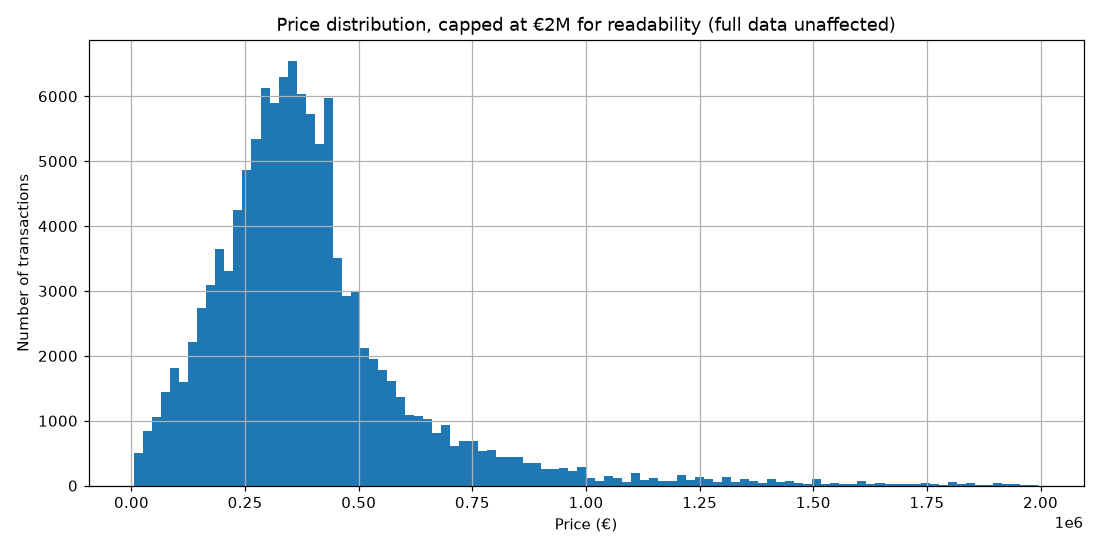

In [1]:
import matplotlib.pyplot as plt

# 99th percentile ~ €1.84M, so capping the VIEW at €2M keeps the real distribution
# visible without letting the bulk-sale outliers crush every other bar
fig, ax = plt.subplots(figsize=(10, 5))
df[df['Price'] < 2_000_000]['Price'].hist(bins=100, ax=ax)
ax.set_xlabel('Price (€)')
ax.set_ylabel('Number of transactions')
ax.set_title('Price distribution, capped at €2M for readability (full data unaffected)')
plt.show()

**Reading the chart:** a sharp peak around €250k–€350k, tapering off in a long right tail — classic right-skewed distribution, matching the mean/median gap above. This is the real shape of the market once the view isn't wrecked by a handful of €80M+ rows sitting off the right edge of the chart.

In [1]:
df['County'].value_counts()

County
Dublin       36938
Cork         13792
Kildare       6792
Galway        5248
Meath         5186
Wicklow       4561
Wexford       4270
Limerick      4177
Louth         3883
Waterford     3130
Tipperary     3009
Donegal       2847
Mayo          2705
Kerry         2563
Clare         2516
Laois         2319
Westmeath     2225
Kilkenny      2115
Sligo         1612
Offaly        1536
Cavan         1533
Roscommon     1462
Carlow        1186
Monaghan       913
Leitrim        907
Longford       893
Name: count, dtype: int64


**Takeaway:** Dublin dominates with ~31% of all transactions (expected — it's Ireland's most populous county). The smallest counties (Longford, Leitrim, Monaghan) still have 800+ transactions over 24 months — enough for a reasonably stable median, so no county needs to be excluded from later county-level comparisons for being statistically too thin.

In [1]:
sorted(df['County'].unique())

['Carlow', 'Cavan', 'Clare', 'Cork', 'Donegal', 'Dublin', 'Galway', 'Kerry', 'Kildare', 'Kilkenny', 'Laois', 'Leitrim', 'Limerick', 'Longford', 'Louth', 'Mayo', 'Meath', 'Monaghan', 'Offaly', 'Roscommon', 'Sligo', 'Tipperary', 'Waterford', 'Westmeath', 'Wexford', 'Wicklow']


**Critical-thinking moment #2:** `nunique()` returning 26 (matching the real number of counties in the Republic of Ireland) is reassuring but not proof by itself — a coincidental total could still hide duplicate spellings (`"Co. Dublin"` vs `"Dublin"`, historical county names). Checked the actual unique values directly rather than trusting the count alone: all 26 are correct, clean county names, no variants or junk values.

In [1]:
df['Property Type'].value_counts()

Property Type
Second-Hand Dwelling house /Apartment    90452
New Dwelling house /Apartment            27866
Name: count, dtype: int64


**Note:** this already reflects a fix made upstream in `data_pipeline.py`. The raw data had a third category, `"Teach/Árasán Cónaithe Atháimhe"` (6 rows) — the Irish-language label for the same "second-hand" category, just recorded inconsistently. It was merged into `"Second-Hand Dwelling house /Apartment"` via `.replace()` inside `clean()`, not patched ad hoc in this notebook — so both this notebook and the dashboard see the same, correct 2-category breakdown, permanently, from a single source of truth.

## Section 3: Outlier Investigation — the Deep Dive

In [1]:
df.nsmallest(10, 'Price')[['Date', 'Address', 'County', 'Price', 'Not Full Market Price']]

             Date                                               Address   County  Price  Not Full Market Price
73623  2025-10-26                         RATHCALLAN, LADYSBRIDGE, CORK     Cork  5,300                   True
26951  2025-01-16                            TREAN, CLEGGAN, CO. GALWAY   Galway  5,500                  False
7247   2024-10-02                     FUCHSIA LODGE, RENVYLE, CONNEMARA   Galway  5,587                   True
39063  2025-04-08                       2 MARYS LANE, BRIDE ST, WEXFORD  Wexford  6,000                  False
47538  2025-05-30              APARTMENT 1, 44 CABRA PARK, PHIBSBOROUGH   Dublin  6,000                  False
66011  2025-09-15                           CORDARRAGH, KILTIMAGH, MAYO     Mayo  6,000                  False
115791 2026-07-09  40 BALLINTEER CRESENT, LISSADELLE ESTATE, BALLINTEER   Dublin  6,000                   True
11582  2024-10-24                          GLENAGARE, LADYSBRIDGE, CORK     Cork  6,025                  False
1

In [1]:
threshold = df['Price'].quantile(0.01)
cheap = df[df['Price'] <= threshold]
cheap['Not Full Market Price'].value_counts(normalize=True)

1st percentile price: 42,000
Not Full Market Price
False   1
True    0


**Nuanced finding (the low end doesn't have a clean explanation):** only **28.8%** of the cheapest 1% of transactions are flagged `Not Full Market Price=True`. So unlike the high end (fully explained by bulk sales), the low end is a mix of flagged non-market sales and seemingly genuine tiny transactions (small land parcels, minority ownership shares) that can't be reliably separated with the fields available. Being honest about this rather than forcing a tidy story: the low end is left as-is, since it's a small share of the data and doesn't meaningfully bias the median.

**Critical-thinking moment #3 — the core design question:** how do we decide, programmatically, which high-price rows are "not really an individual home sale"? A flat price cutoff (e.g. exclude everything above €5M) was the first idea — simple, but two problems: it would treat a large **and** a small bulk sale identically regardless of how many units were involved, and it risks excluding genuinely expensive **individual** homes just because they're rare.

In [1]:
import re

# Text signals for multi-unit/bulk sales, based on real examples seen above
pattern = re.compile(
    r'\bblocks\b'                                  # plural 'Blocks' (A & B, B and C, etc.)
    r'|\bsite for\b'                                # development site, not a built dwelling
    r'|\b\d+\s*units?\b'                          # '189 units', '77 units'
    r'|\b\d+\s*(?:residential\s+)?apartments?\b' # '111 APARTMENTS', '47 Apartments'
    r'|\b\d+\s*-\s*\d+\b'                       # address number ranges: '1-118', '83-188'
    r'|\b\d+\s+to\s+\d+\b',                     # '1 to 44'
    re.IGNORECASE
)
df['flag_address'] = df['Address'].str.contains(pattern, regex=True)
df['flag_price_5m'] = df['Price'] > 5_000_000
print('Flagged by address pattern:', df['flag_address'].sum())
print('Flagged by >€5M price:', df['flag_price_5m'].sum())
print('Overlap (both flags):', (df['flag_address'] & df['flag_price_5m']).sum())

Flagged by address pattern: 538
Flagged by >€5M price: 290
Overlap (both flags): 164


**Result — the address pattern is genuinely better calibrated than price alone, in both directions:**
- It catches **374 smaller bulk sales** that price alone misses entirely — e.g. `"10 units at Miller's Glen, Swords"` at €4.83M, which totals under €5M but is clearly a multi-unit sale, not one expensive home.
- It correctly **leaves legitimate expensive individual homes alone** that a flat price cutoff would have wrongly excluded — e.g. `"81 AILESBURY RD, DONNYBROOK, DUBLIN 4"` (€10M) and `"39 CASTLEPARK ROAD, DALKEY"` (€5.95M) are single addresses on genuinely Ireland's most expensive streets, with no bulk-sale language.

**Known gap:** it still misses irregular multi-address listings with no clean keyword or number range, e.g. `"2 The Mews and 68 The Boulevard, and 1 2 3 The Plaza, Hollystown"` (€7.1M) — obviously bulk, but phrased in a way the regex doesn't catch. A real, disclosed limitation rather than a solved problem.

**Critical-thinking moment #4 — the user's idea:** rather than relying on address text alone, compute a *typical price per county* and flag anything unusually high relative to its own area — since "expensive" means something different in Dublin vs. a rural county. The immediate self-caught problem: if the average used to detect outliers is itself computed *including* the outliers, it's a circular, self-defeating measure — the very rows you're trying to catch drag the baseline up, making them look less extreme than they are. This is a real, well-known statistics trap, and spotting it *before* building it is exactly the right instinct.

In [1]:
def upper_bound(s, k=3):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q3 + k * iqr

bounds = df.groupby('County')['Price'].apply(upper_bound)
df['flag_stat_raw'] = df['Price'] > df['County'].map(bounds)
print('Dublin bound (raw price):', bounds['Dublin'])
print('Total flagged:', df['flag_stat_raw'].sum())

Dublin bound (raw price): 1,450,000
Total flagged: 2836


**First attempt (median/IQR, but on raw prices) — this failed, and the failure is informative.** The fix for the circularity problem is to use **median and percentiles instead of mean** — percentiles only depend on rank/position in the sorted data, not magnitude, so a handful of €100M+ rows barely move Q1/Q3 at all. That part worked. But the *result* was still wrong: the Dublin bound came out to just **€1,450,000**, flagging **2,836 rows** (2.4% of the data) — including `"82 AILESBURY RD, BALLSBRIDGE, DUBLIN 4"` at €3.1M, an almost-certainly legitimate expensive Dublin home. Reason: house prices are naturally right-skewed even *without* any bulk sales, and a linear IQR multiplier assumes a roughly symmetric distribution — it doesn't handle a naturally long genuine tail well.

In [1]:
import numpy as np

# Standard fix for IQR on a right-skewed distribution: apply it to log(Price).
# Logging pulls a naturally skewed distribution back toward symmetric, which
# is the shape IQR assumes.
df['log_price'] = np.log(df['Price'])

log_bounds = df.groupby('County')['log_price'].apply(upper_bound)
df['county_log_bound'] = df['County'].map(log_bounds)
df['county_price_bound'] = np.exp(df['county_log_bound'])
df['flag_statistical'] = df['log_price'] > df['county_log_bound']

print('Dublin bound (log-based):', df.loc[df.County=="Dublin", "county_price_bound"].iloc[0])
print('Total flagged:', df['flag_statistical'].sum())

Dublin bound (log-based): 3,312,186
Total flagged: 640


In [1]:
checks = ['82 AILESBURY RD', '81 AILESBURY RD', '14 COOLATREE CLOSE', '14 COOLATREE PARK',
          '1 KEEPERS LOCK, CLONBURRIS, CLONDALKIN']
for name in checks:
    row = df[df['Address'].str.contains(name, case=False, na=False)]
    print(row[['Address', 'County', 'Price', 'flag_statistical']].to_string())

                                    Address  County     Price  flag_statistical
209  82 AILESBURY RD, BALLSBRIDGE, DUBLIN 4  Dublin 3,100,000             False

                                    Address  County      Price  flag_statistical
5366  81 AILESBURY RD, DONNYBROOK, DUBLIN 4  Dublin 10,000,000              True

                                      Address  County      Price  flag_statistical
42223  14 COOLATREE CLOSE, BEAUMONT, DUBLIN 9  Dublin 18,391,889              True

                                     Address  County   Price  flag_statistical
81425  14 COOLATREE PARK, BEAUMONT, DUBLIN 9  Dublin 660,000             False

                                      Address  County      Price  flag_statistical
76378  1 KEEPERS LOCK, CLONBURRIS, CLONDALKIN  Dublin 21,090,974              True


**Second attempt (median/IQR on log-transformed price) — this worked well.** Dublin's bound moved to a much more sensible **€3,312,186**, flagging **640 rows** (0.54% of the data). Spot checks against known cases:
- `"82 AILESBURY RD"` (€3.1M) → **not flagged** — correctly recognized as a legitimate expensive Dublin home
- `"14 COOLATREE CLOSE, BEAUMONT"` (€18.4M) → **flagged**, while `"14 COOLATREE PARK, BEAUMONT"` (€660k), a normal neighbouring address, is **not** — the method distinguishes a genuine anomaly from an ordinary comparable a few doors away
- `"1 KEEPERS LOCK, CLONBURRIS"` (€21.1M) → **flagged**, and every *other* unit in that exact development (21, 31, 41, 51, 71 Keepers Lock Park) sold for a completely normal €396k–€471k — about as clean a confirmation as you'll get that this one row is a genuine data anomaly.

**Honest remaining ambiguity:** `"81 AILESBURY RD"` (€10M) also gets flagged, and this one is genuinely debatable — Ailesbury Road is real enough as an ultra-expensive Dublin street that a legitimate €10M sale isn't impossible, just extreme even for that street. No method available from these fields can fully resolve "extremely expensive but real" vs. "wrong" with certainty — that's a disclosed limitation, not a bug.

In [1]:
# Combine both signals: a row is flagged if EITHER method catches it, since
# they catch genuinely different things (labeled bulk sales vs. unlabeled
# statistical anomalies with no textual clue at all)
df['likely_bulk_or_anomalous'] = df['flag_address'] | df['flag_statistical']
print('Combined flagged:', df['likely_bulk_or_anomalous'].sum(),
      f"({100 * df['likely_bulk_or_anomalous'].mean():.2f}%)")

Combined flagged: 891 (0.75%)


**Decision:** flag a row as `likely_bulk_or_anomalous` if the address pattern **OR** the per-county log-IQR statistical test catches it — 891 rows (0.75% of the data). Not deleted from the dataset — kept as a boolean flag, same pattern as `Not Full Market Price`, so:
- Default dashboard views (median price, "most expensive sales" table) exclude these rows
- A toggle can still show everything, for anyone who wants the unfiltered view
- Nothing is silently destroyed from the underlying data

**Next step:** bake this flag into `data_pipeline.py`'s `clean()` function, same as the `Property Type` and `Size Band` fixes — so the notebook, the dashboard, and any future re-run all agree, rather than this logic living only here.

## Data Quality Columns — What They Mean and Why They Matter

**`Not Full Market Price`** — flags a transaction where the recorded price may not reflect true open-market value (family transfers, shared-ownership schemes, other non-arm's-length sales). It's an active input to the analysis: it becomes a dashboard filter, and whether including/excluding it changes the median is a real methodology question (queued up in Section 7 below, not yet run). It only explains ~29% of the cheapest transactions, so it's a partial signal, not a magic filter.

**`Size Band`** — meant to record floor area category for new builds. PSRA stopped populating it for recent transactions (100% empty in this 24-month window, confirmed by checking the raw source data directly, not just this filtered file). Its role here is almost entirely negative: dropped from the pipeline output, documented as a known limitation (no price-per-size analysis is possible with current data), rather than silently never mentioned.

## Next Steps (Not Yet Run)

The following sections of the original EDA plan are still open:

- **Section 4 — Missingness patterns:** is `Eircode` missing randomly, or concentrated in specific (likely rural) counties? Matters because it would mean any Eircode-based analysis is urban-biased.
- **Section 5 — Bivariate analysis:** median price by county (bar chart) and by property type; boxplot of price by top counties to show spread, not just center.
- **Section 6 — Time trend:** monthly transaction volume and monthly median price — is there an actual trend in this 24-month window, or is it closer to flat/noisy?
- **Section 7 — The `Not Full Market Price` question:** compute median price with vs. without these rows included, nationally and for top counties — decide the dashboard's default toggle state based on the actual size of the effect, not a guess.
- **Section 8 — Final written conclusions:** 3–5 sentence summary tying every finding above into what actually goes into the README and shapes the dashboard's default filters.

Also pending: fold the `likely_bulk_or_anomalous` flag from Section 3 into `data_pipeline.py`, so it's a permanent, single-source-of-truth column rather than something only this notebook knows about.